# Lab 3 : Training and Evaluating a Variational Autoencoder
## Polytech Paris-Saclay : Machine Learning II
### Name : Marko BABIC


___
## Goals
___

The goal of this lab is to build a simple Variational autoencoder (VAE) using PyTorch and to become familiar with its main components (Encoder, Decoder…).

To do this, we will implement this network with the PyTorch library and we will train and evaluate it on the
MNIST dataset.

___
## Section 1 - Theoretical foundation
___

### 1.1 NEURAL NETWORKS TRAINING

Neural networks are powerful non-linear approximators used to learn non-linear relationships between
an input vector and an output vector. The more the neurons, i.e., the more the parameters, the lower the errors they can attain.

However, overfitting is behind the corner.

**1. What is overfitting? What it is due to?**

Overfitting happens when a model learns the training data "too well," including its noise and specific details, but fails to generalize to new, unseen data. It has low error on training data but high error on test data.

There are different reasons :

* It can come from the quality of the data : The training set is too small or not representative of the real world.  For instance if the model is trained on only patients that have cancer, in front of new data of patients that do not have cancer, the model will get wrong.

* It can come from a  model that is too complex, allowing it to "memorize" rather than learn.


**2. How do you avoid overfitting when training deep neural networks?**

To avoid overfitting, we use Regularization techniques or improve the data :

* L2 Regularization (Weight Decay)
* Dropout
* Early Stopping
* Data Augmentation (increasing the size/diversity of data)
* Reducing the network complexity (fewer layers or neurons)

**3. What is early stopping and why does it help with overfitting?**

Early stopping acts as a regularizer by monitoring the validation error during training. Instead of training for a fixed number of epochs, training is stopped as soon as the validation error begins to increase.

It prevents the model from continuing to optimize on the training set to the point where it starts memorizing noise, effectively freezing the model at the point of best generalization.

**4. What is weight decay and why does it help with overfitting?**

Weight decay adds a penalty term to the loss function proportional to the magnitude of the weights ($λ||w||^2$).

It forces the network to keep the weights small. Smaller weights mean the network is less sensitive to small changes in the input and less likely to model the noise in the training data.

**5. What is dropout and why does it help with overfitting?**

Dropout is a technique where, during each training iteration, a random subset of neurons is ignored with a probability p.

First, it prevents co-adaptation: Neurons cannot rely on specific other neurons to correct their mistakes, forcing them to learn more robust and independent features.

Then it simulates training a large number of different neural networks and averaging their predictions, which reduces variance.

### 1.2 RECURRENT NEURAL NETWORKS

Sequential data such as text, time series, and sensor streams are often processed via recurrent neural networks (RNN).

**1. Do we really need a recurrent neural network to process a stream of input data?**

RNNs are not strictly necessary to process a stream of input data even if they are designed for it.

We have also other architecture that work with sequential data such as Transformer, CNN or Feedforward Networks.

Some of these other architectures are faster or more accurate than the RNN.

**2. Classic recurrent neural networks suffer the vanishing gradient problem. What is it and what is it due to? Does it affect only recurrent networks?**

**What is vanishing gradient ?**


During training, the network updates its weights using gradients calculated from the output error and propagated backward. The vanishing gradient problem occurs when these gradients become exponentially small as they are propagated back through many layers or time steps.

As a result, the weights in the initial parts of the network are barely updated, and those parts stop learning.

**What is it due to ?**

In Neural Networks, training involves backpropagation, which means using the chain rule that involves multplication of derivatives of functions.
$$
\frac{\partial c}{\partial a} = \frac{\partial c \partial b}{\partial b\partial a}
$$

If the weights are small or the activation function's derivative is less than 1 (like tanh or sigmoid), this repeated multiplication causes the gradient signal to reduce exponentially fast.

For instance the derivative of the sigmoid will outputs a value between (0,0.25).
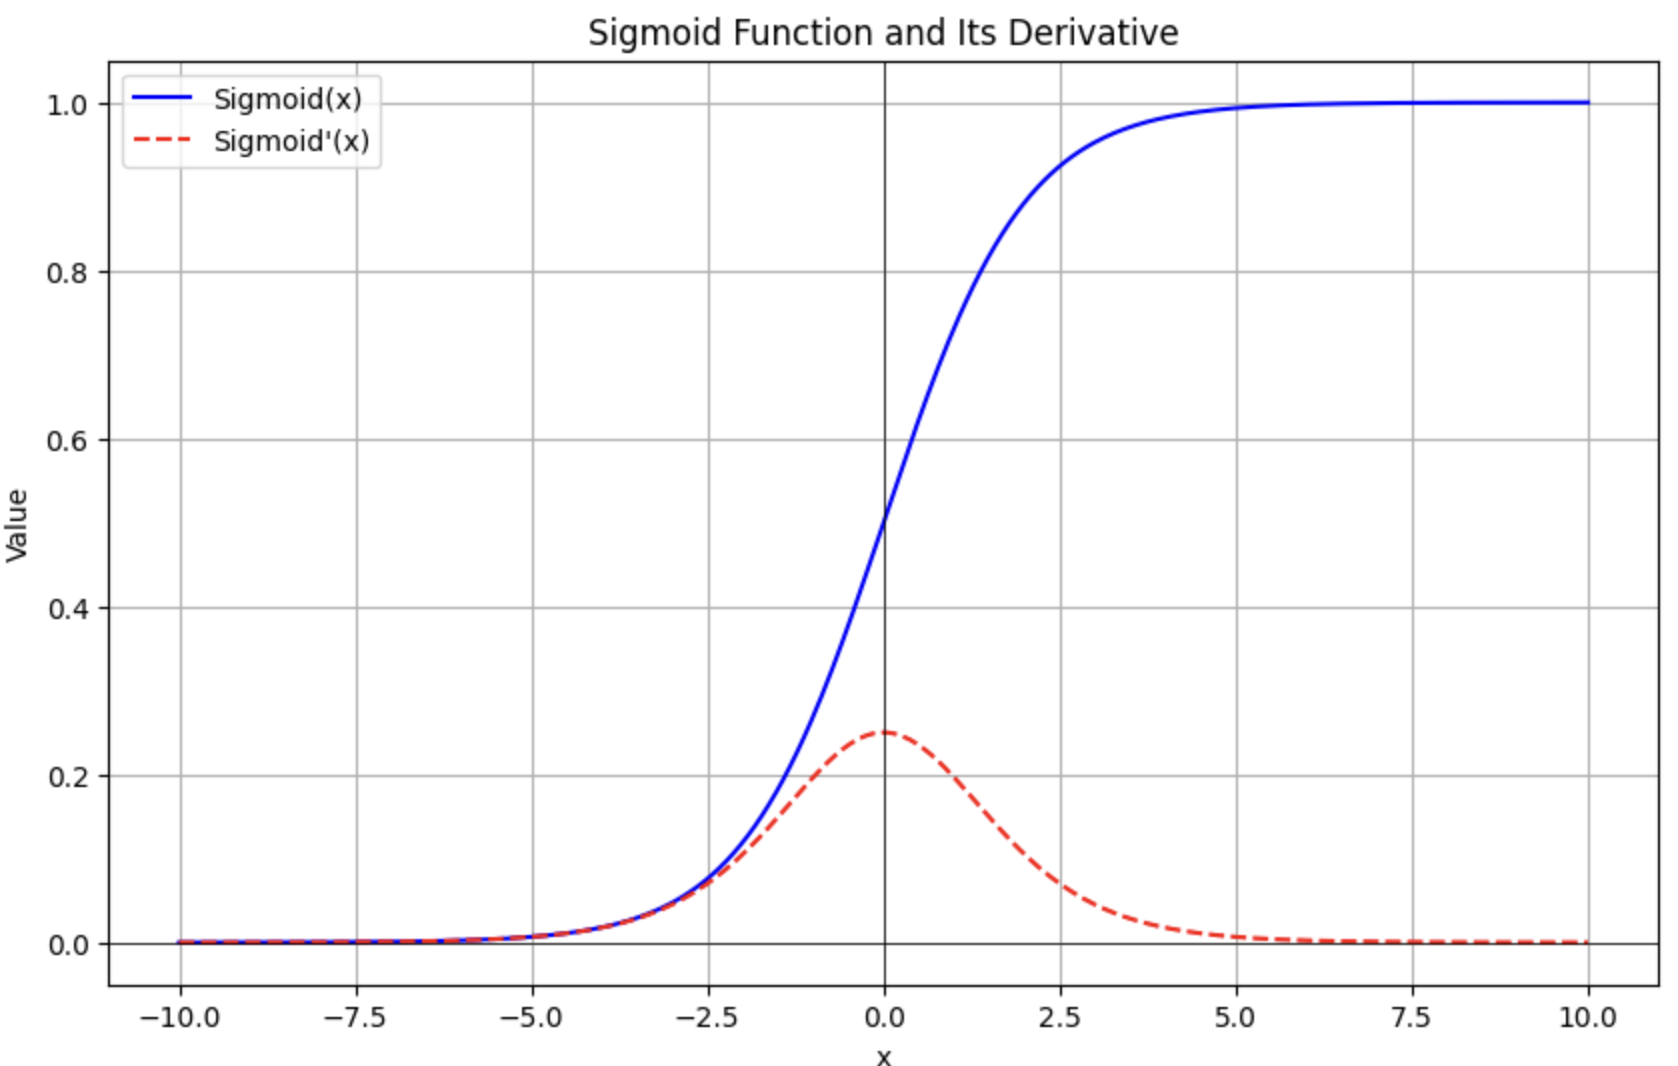

**Does it affect only recurrent networks?**

No. It affects neural network with many layers. RNNs are just a common example because processing long sequences is equivalent to training a very deep network.

**3. What is ReLU and why it helps with vanishing gradient?**

**What is ReLU ?**


ReLU (Rectified Linear Unit) is an activation function defined as $f(x) = \max(0, x)$. It outputs the input directly if it is positive, otherwise, it outputs zero.
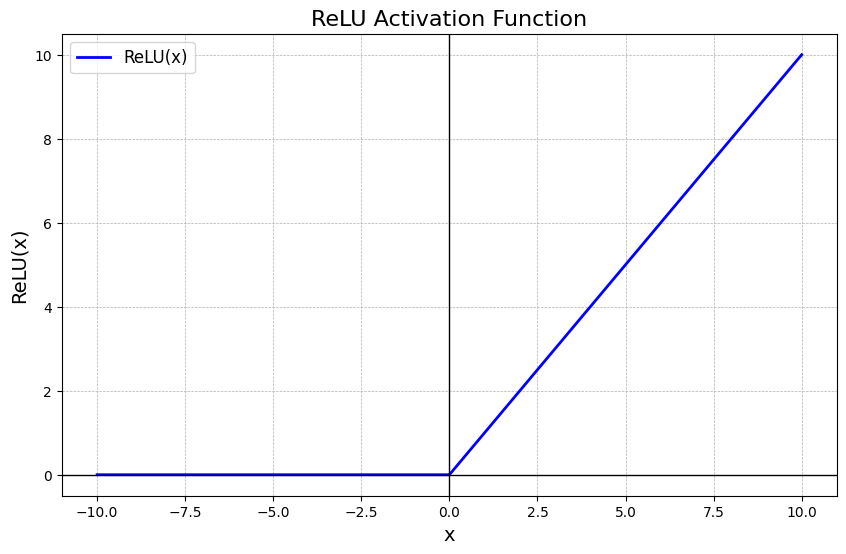

**Why it helps with vanishing gradient?**

As we saw just before, the derivative of an activation function has a direct influence on the vanishing gradient problem. Therefore, having an activation function that has a derivative that does not decrease an input becomes important.

For positive inputs ($x > 0$), the derivative of ReLU is always 1. Unlike Sigmoid or Tanh, whose derivatives are always $< 1$ , ReLU preserves the gradient's magnitude during backpropagation for active neurons. This allows gradients to flow through many layers without vanishing.

For negative inputs ($x \leq 0$), The derivative is 0. This completely blocks the gradient for that neuron. While this causes the "Dead ReLU" problem (where neurons stop learning), it actually creates sparsity in the network, which can be computationally efficient, rather than causing the classic vanishing gradient problem.



**4. What is an LSTM and why it helps with vanishing gradient?**

**What is an LSTM?**

LSTM(Long Short-Term Memory Networks) layer is a type of RNN designed to capture long-term dependencies in sequential data. Unlike a standard RNN, it has a memory cell and three gates (Forget, Input, and Output) that regulate the flow of information.

Forget Gate: Decides what information to throw away from the previous cell state (filters history).

Input Gate: Decides what new information to store in the cell state.

Cell Update: Combines the filtered old state and the new information to create the new memory.

Output Gate: Decides what to output (the hidden state) based on the new cell state.

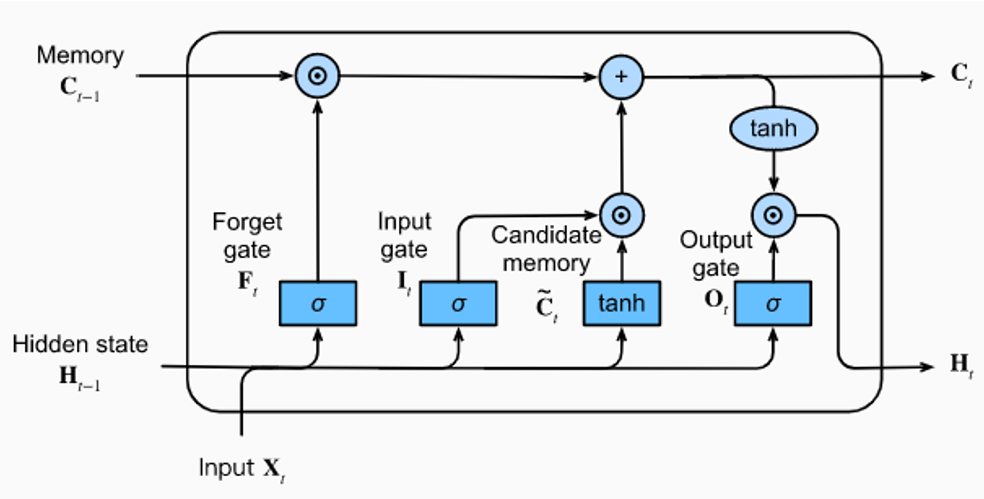

**Why it helps with vanishing gradient?**

It helps in the step of **Cell Update**. Indeed, in a standard RNN, the state is updated via matrix multiplication, which causes gradients to shrink (vanish) over time.
In an LSTM, the cell state is updated additively:
$$C_t = (C_{t-1} \times f_t) + (i_t \times \tilde{C}_t)$$

where:

* $C_{t-1}$: Old cell state (previous memory).
* $f_t$: Output of the Forget Gate (vector of values between 0 and 1).
* $i_t$: Output of the Input Gate (how much we update the cell).
* $\tilde{C}_t$: Candidate new values to be added.

This additive structure allows gradients to flow backward through time without being repeatedly multiplied by small numbers. So it helps with vanishing gradient.

### 1.3 TRANSFORMERS

Sequence-to-Sequence models are machine learning architectures designed to convert sequences
from one domain into sequences in another. The fundamental structure of a Sequence-to-Sequence
model relies on the encoder-decoder framework.

**1. What is sequence to sequence modeling? How does the attention mechanism is used in
Sequence-to-Sequence modeling?**


Sequence-to-sequence (Seq2Seq) models are a type of neural network architecture used for instance in NLP and in translation. They consist of an encoder and a decoder network.

The encoder takes an input sequence and converts it into a fixed-size context vector, capturing the input sequence’s information. It can be a RNN or LSTM or Gated Recurrent Units (GRU) to process the input sequence.

The decoder then generates an output sequence based on this context vector from the encoder. It can also be a RNN or LSTM or GRU.


**Attention mechanism in Sequence-to-Sequence modeling**

In traditional Seq2Seq models, the Encoder must compress the entire input into a single fixed-length vector. This can cause information loss for long sequences.

Attention solves this by allowing the Decoder to "look back" at the entire input sequence at every step :

- For each output step, the model calculates "scores" to determine which parts of the input are most relevant.
            
  - Assigns weights to different parts of the input sequence with
  $$Attention(Q,K,V) = softmax(\frac{QK^T}{\sqrt{d_k}})\times V$$
  $$(Q:Query,K:Keys, V:Values)$$

- It assigns higher weights to relevant input parts (e.g., when generating the French word "Chat", it focuses on the English word "Cat").

- It creates a dynamic context vector (a weighted sum of inputs) specifically for that decoding step.

- Instead of reading a whole sentence, closing its eyes, and trying to translate it from memory, Attention look back at the original sentence and focus on the specific words we are currently translating.


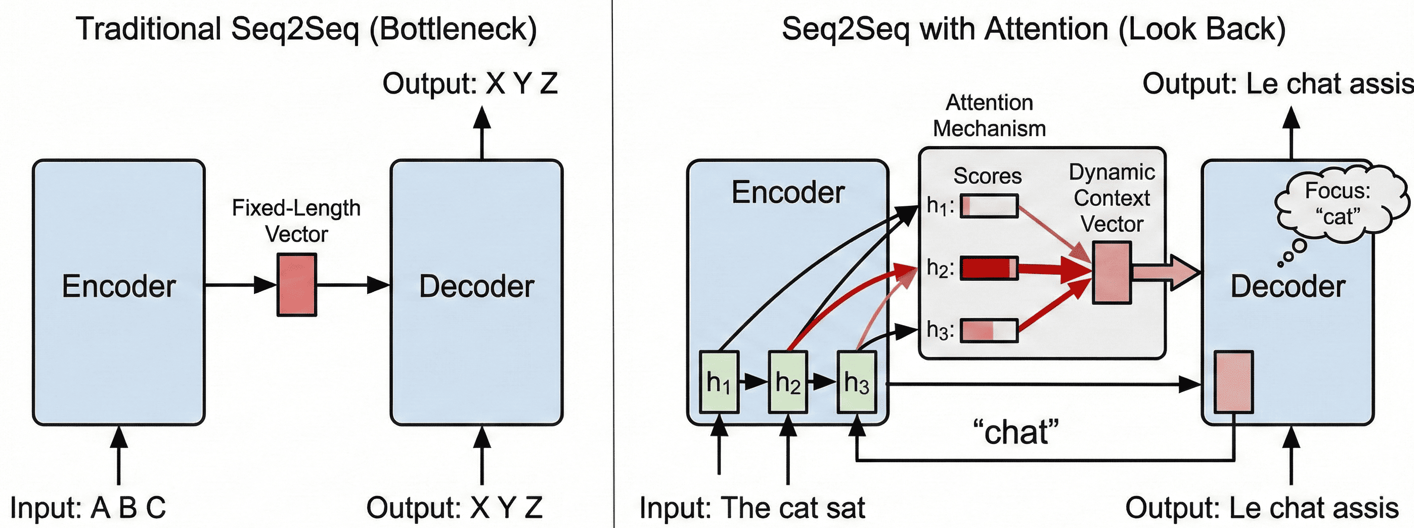

**2. Why do we need an attention mechanism? Aren't Long Short-Term Memories enough?**

**Why we need Attention:**

Instead of relying on one static context vector, Attention gives the decoder access to the entire history of encoder states.

It allows the model to "search" for relevant information in the source sentence at every step of decoding, regardless of how long the sequence is or how far back the information is located.

**Why LSTMs have limits:**

LSTMs are not always enough especially for long sequences.
Even though LSTMs are designed to handle long-term dependencies better than simple RNNs, they still suffer from the fixed-length vector bottleneck.

In a standard Seq2Seq LSTM, the Encoder must compress the entire meaning of a long sentence (or document) into a single context vector (the final hidden state).

For very long sequences, this vector becomes "cluttered," and information about the beginning of the sequence tends to be lost or diluted by the time the decoder starts generating.


LSTMs improve memory, but **Attention improves access to that memory**.

**3. What are the advantages and disadvantages of the following neural network architectures:
RNNs, LSTM and Transformers?**

**RNNs**
* Advantages:
  - Naturally handles data where order matters (sequential data).
  - Can process inputs of any length.
  - Simpler architecture with fewer parameters than LSTMs or Transformers.
* Disadvantages:
  - Short-term memory : Suffers severely from the vanishing gradient problem, making it unable to learn long-term dependencies.
  - Slow Training: Computation is sequential (step $t$ depends on $t-1$), so it cannot be **parallelized**.

**LSTM**
* Advantages:
  - Solves the vanishing gradient problem using gates, allowing it to learn dependencies over longer sequences.
  - More stable training for sequences than RNNs.

* Disadvantages:
  - More parameters and gates make it computationally heavier and slower to train than simple RNNs.
  - Like RNNs, they still process data sequentially, preventing parallelization on GPUs.

**Transformers**
* Advantages:
  - Processes the entire sequence at once (not sequentially), allowing for massive parallelization and much faster training.
  - The Attention mechanism allows it to model dependencies between any two words in a sequence instantly, regardless of distance (global context).
  
* Disadvantages:
  - The attention mechanism has quadratic complexity ($O(n^2)$), meaning memory usage explodes for very long sequences.
  - Generally requires more training data to generalize well compared to RNNs/LSTMs.
  - Since it has no inherent sense of order/time, positional information must be manually added(positional encoding). Each position in the sequence has a unique mathematical vector associated with it. We add this vector to the word's meaning (embedding). The model can then learn to distinguish between "cat" in position 2 (subject) and "cat" in position 5 (object) because their final representation will be slightly different due to the added positional information.

**4. What are real-world applications of Sequence-to-Sequence models?**


Translation: The model takes a sentence in one language  and outputs the translation in another.

Text Summarization: Taking a long document or news article as input and generating a short, concise summary as output.

Speech Recognition (ASR): Converting a sequence of audio signals into a sequence of text.

Chatbots and Conversational AI: Taking a user's message as input and generating a relevant, context-aware text response as output (like ChatGPT).

Code Generation: Translating a natural language description (e.g., "Create a function to sort a list") into a sequence of programming code.

### 1.4 AUTO-ENCODERS AND VARIATIONAL AUTO-ENCODERS

**Autoencoders (AEs)** are a type of neural network designed to learn efficient data representations for the purpose of dimensionality reduction or feature learning.

The primary objective of autoencoders is to minimize the difference between the input and the reconstructed output, thus learning a
compact representation of the data.

**Variational Autoencoders (VAEs)** extend the capabilities of the traditional autoencoder framework by incorporating probabilistic elements into the encoding process.
While standard autoencoders map inputs to fixed latent representations, VAEs introduce a
probabilistic approach where the encoder outputs a distribution over the latent space.

**1. What is the relationship we learn in a neural autoencoder? Why we do it?**

An Autoencoder learns an approximation of the Identity Function, meaning it tries to learn a mapping where the output is as close as possible to the input:
$$\hat{x} = f(x) \approx x$$

Encoder maps the input $x$ to a lower-dimensional latent representation $z$  and decoder reconstructs the input $\hat{x}$ from $z$.

If the network just copied the input to the output perfectly, it would be useless. By imposing a bottleneck (making the hidden layer $z$ smaller than the input), we force the network to compress data. Therefore, it learns the most important features (dimensionality reduction) while ignoring noise. We have also a more efficient reprentation of the data

This appoximative replication helps also to generate new and similar data compared to the input, helping to remove noise from an image for example.

**2. What is the difference between an autoencoder and a variational autoencoder?**

These 2 architectures have a different goal. The primary goal of AE is representation learning (compression). It learns a direct mapping from an input $x$ to a fixed vector $z$ (latent code) and back to $x$.
While VAE's primary goal is generation. It learns the probability distribution of the input data so that it can sample new, unique data points from that distribution.

Then the main difference is in the latent space. The encoder in a VAE maps the input data to a probability distribution over the latent variables (typically modeled as a Gaussian distribution with mean μ and variance $σ^2$).

This approach encodes each input into a distribution rather than a single point, adding a layer of variability and uncertainty.

While AE uses reconstruction loss (for example MSE), VAE uses reconstruction loss + KL Divergence. The KL Divergence term forces the learned distributions to stay close to a standard Normal distribution ($N(0,1)$), ensuring the latent space remains well-structured.

An Autoencoder learns to compress specific points. A VAE learns to describe the data as a statistical distribution, allowing generation of new content.

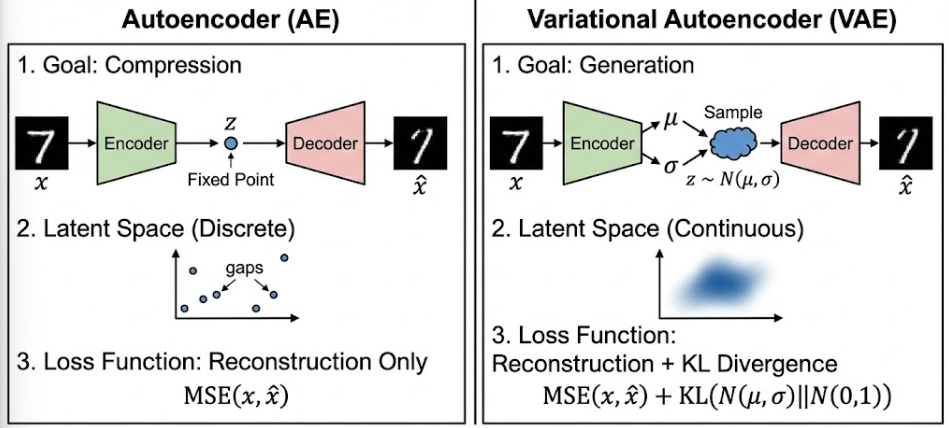

**3. What are variational autoencoders used for?**

Image Generation: Creating new, realistic images

Denoising: Removing noise from images by encoding the noisy image and decoding a clean version (learning the "essence" of the image).

Edit image : Smoothly morphing one image into another (for example, changing a facial expression from sad to happy) by navigating the continuous latent space.

Data Augmentation: Generating new synthetic training data to improve the performance of other machine learning models when real data is doesn't exist.

Anomaly Detection: Since VAEs learn the distribution of "normal" data, they can detect anomalies by flagging inputs that have a high reconstruction error (meaning the model doesn't recognize them).

**4. What are the benefits of variational autoencoders?**

The main benefits of VAEs come from their structured and continuous latent space. Indeed, Unlike standard Autoencoders, VAEs can generate new, realistic data (e.g., images, text) that wasn't in the training set by simply sampling random points from the latent space ($z \sim N(0,1)$).

Because the latent space is continuous, we can take two data points and smoothly morph one into the other by "walking" along the line connecting them in the latent space.

Moreover, VAEs often learn to separate different features of the data into different dimensions of the latent space (for intance, one dimension might control "smile," another "hair color"). This makes the learned features meaningful and interpretable.

Finally, AEs map inputs to precise points in latent space, meaning even slight noise can push an input to an incorrect point. In contrast, VAEs are probabilistic and map inputs to a "cloud" (distribution) rather than a single point, allowing them to absorb noise and map imperfect inputs to the correct general region. This "fuzziness" allows the model to handle ambiguity and uncertainty gracefully, as overlapping distributions can represent inputs that could validly be interpreted in multiple ways (in MNIST case, a digit looking like both a 1 and a 7).

**5. Why use a variational autoencoder instead of an autoencoder?**

We choose VAE if:

* We want to generate new, realistic samples from scratch.

* We want to smoothly interpolate between data points (like morphing image A into image B).

* We need a structured, continuous latent space where every point decodes to something meaningful.

We choose Standard AE if:

* We only care about compressing data and reconstructing it exactly.

**6. What are the advantages and disadvantages of variational autoencoders?**

**Advantages**

 - Continuous Latent Space: VAEs learn a smooth, structured latent space. This allows to interpolate between two data points (e.g., morphing a face into another) or modify specific features (e.g., adding glasses) by moving in that space.

 - They are based on solid probabilistic theory (Bayesian inference), making them mathematically grounded and capable of estimating the likelihood of data (useful for anomaly detection).

**Disadvantages**

 - Blurry Outputs: VAEs tend to generate images that look slightly "fuzzy" or out of focus. In fact the reconstruction loss creates an "average" of all plausible possibilities to minimize error, rather than picking one sharp, realistic detail.

 - Balancing the Loss: It can be tricky to balance the two parts of the loss function (Reconstruction vs. KL Divergence). If the KL term is too strong, the model ignores the input.  If it's too weak, the latent space loses its structure (becoming just a standard autoencoder).

___
## Section 2 – Implementation
___

The objective of this part is to implement a Variational Autoencoder (VAE) with PyTorch and to
train and evaluate it on the MNIST dataset.

This part is inspired by the PyTorch getting started tutorial available at https://docs.pytorch.org/tutorials/beginner/pytorch_with_examples.html.


### 2.1 Setting up the environment

In [ ]:
!pip install torch torchvision matplotlib numpy

### 2.2 Step-by-step Implementation of a Variational Autoencoder (VAE)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

Then we define the architecture of encoder, decoder and VAE

In [ ]:
class Encoder(nn.Module):
  def __init__(self, input_dim, hidden_dim, latent_dim):
    super(Encoder, self).__init__()
    self.fc1 = nn.Linear(input_dim, hidden_dim) #fully connected layer transforming input_dim to hidden_dim

    #  fully connected layers transforming hidden_dim to latent_dim.
    self.fc_mu = nn.Linear(hidden_dim, latent_dim)
    self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

  # applies ReLU to fc1 output, then computes mu and logvar
  def forward(self, x):
    h = torch.relu(self.fc1(x))
    mu = self.fc_mu(h)
    logvar = self.fc_logvar(h)
    return mu, logvar

# Decoder class
#inheriting from nn.Module
class Decoder(nn.Module):
  def __init__(self, latent_dim, hidden_dim, output_dim):
    super(Decoder, self).__init__()
    self.fc1 = nn.Linear(latent_dim, hidden_dim)#fc1 is a fully connected layer transforming latent_dim to hidden_dim.
    self.fc2 = nn.Linear(hidden_dim, output_dim)#fc2 is a fully connected layer transforming hidden_dim to output_dim

  # applies ReLU to fc1 output, then sigmoid to fc2 output.
  def forward(self, z):
    h = torch.relu(self.fc1(z))
    # Sigmoid
    x_hat = torch.sigmoid(self.fc2(h))
    return x_hat

# VAE class
# Init encoder and decoder
class VAE(nn.Module):
  def __init__(self, input_dim, hidden_dim, latent_dim):
    super(VAE, self).__init__()
    self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
    self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

  def forward(self, x):
    # Encode input to latent distribution parameters
    mu, logvar = self.encoder(x)

    # This allows backpropagation through the random node
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)# Random noise from standard normal distribution
    z = mu + eps * std #Compute latent variable

    # Decode z to reconstruct the input
    x_hat = self.decoder(z)
    return x_hat, mu, logvar

We also have to define the loss function. The loss function for VAEs consists of a reconstruction loss and
a KL (Kullback-Leible) divergence loss.

In [ ]:
def loss_function(x, x_hat, mu, logvar):
  BCE = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum') #cross entropy loss
  KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) #Kullback-Leibler (KL) Divergence
  return BCE + KLD

**Question: Provide the explanation of the code**

The VAE loss function combines 2 functions :

* Reconstruction: Make the output look like the input.
* Regularization: Make the latent space structured and continuous (like a standard Normal distribution).

#### Reconstruction Loss(BCE)

In first line, we measure how well the Decoder reconstructed the input with a binary cross entropy. Since we used a sigmoid activation in the decoder, we treat each pixel intensity as a probability. It compares the original input pixel x with the reconstructed pixel x_hat. If they are different, the loss increases.
$$\text{BCE} = - \sum_{i=1}^{N} \left[ x_i \cdot \log(\hat{x}_i) + (1 - x_i) \cdot \log(1 - \hat{x}_i) \right]$$


```
reduction='sum'
```
 We sum the errors across all pixels to get the total reconstruction error for the image.

#### KL Divergence(KLD)
The second lines defines a regularizer. It forces the encoder's output distribution (defined by mu and logvar) to be as close as possible to a Standard Normal Distribution ($N(0, 1)$). Without this, the encoder would just "cheat" by memorizing distinct points (like a standard autoencoder) and we wouldn't be able to generate new data by sampling.

$$D_{KL} = -0.5 \sum (1 + \log(\sigma^2) - \mu^2 - \sigma^2)$$

#### Total Loss
We minimize the sum of both.
If BCE is too high,the images look bad. If KLD is too high, the latent space is messy, and we can't generate new images.

The model learns to balance these two to generate good images from a smooth latent space.

### 2.3 Training the VAE
We will load the MNIST dataset and define the optimizer.

In [ ]:
import time

# Hyperparameters
input_dim = 784
hidden_dim = 400
latent_dim = 20
lr = 1e-3
batch_size = 128
epochs = 10

def train_vae(input_dim,hidden_dim,latent_dim,lr,batch_size,epochs) :
  # Data loader
  transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
  train_dataset = datasets.MNIST(root='./data', train=True, transform=transform,download=True)
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

  # Model, optimizer
  vae = VAE(input_dim, hidden_dim, latent_dim)
  optimizer = optim.Adam(vae.parameters(), lr=lr)

  # Start Timer
  start_time = time.time()

  #For comparing the loss after epochs(convergence)
  initial_loss = 0
  final_loss = 0

  # Training loop
  vae.train()
  for epoch in range(epochs):
    train_loss = 0
    for x, _ in train_loader:
      x = x.view(-1, input_dim)
      optimizer.zero_grad()
      x_hat, mu, logvar = vae(x)
      loss = loss_function(x, x_hat, mu, logvar)
      loss.backward()
      train_loss += loss.item()
      optimizer.step()

    avg_loss = train_loss / len(train_loader.dataset)
    # Capture initial loss for comparison
    if epoch == 0:
      initial_loss = avg_loss
    print(f"Epoch {epoch + 1}, Loss: {avg_loss:.2f}")
    final_loss = avg_loss

  return vae,train_loader

  # End Timer
  end_time = time.time()
  total_time = end_time - start_time
  print(f"####################################")
  print(f"#### => The training is done <= ####")
  print(f"Total Time: {total_time:.2f} sec")
  print(f"Time per Epoch: {total_time/epochs:.2f} sec")
  print(f"Convergence: Loss dropped from {initial_loss:.2f} to {final_loss:.2f}")
  print(f"####################################")

In [ ]:
first_train = train_vae(input_dim,hidden_dim,latent_dim,lr,batch_size,epochs)

Epoch 1, Loss: 165.16
Epoch 2, Loss: 121.50
Epoch 3, Loss: 114.49
Epoch 4, Loss: 111.52
Epoch 5, Loss: 109.76
Epoch 6, Loss: 108.58
Epoch 7, Loss: 107.74
Epoch 8, Loss: 107.06
Epoch 9, Loss: 106.55
Epoch 10, Loss: 106.13


**1. Provide the explanation of the code.**

#### Hyperparameters

```
input_dim = 784
```
The input size. Since MNIST images are $28 \times 28$ pixels, we flatten them into a vector of size $784$

```
hidden_dim = 400
```
The size of the hidden layer between the input and the latent space
```
latent_dim = 20
```
We are compressing the 784-pixel image into just 20 numbers.
```
batch_size = 128
```
The model learns from 128 images at a time (stochastic gradient descent).

#### Data Loader
```
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])
```
We create a pipeline to transform the raw images.
```ToTensor()``` converts images to PyTorch tensors and scales pixel values to the $[0, 1]$ range.

```view(-1)``` flattens the image from a 2D matrix ($1 \times 28 \times 28$) to a 1D vector ($784$). This is necessary because our model uses fully connected Linear layers, not Convolutional layers.

#### Training Loop

```
for x, _ in train_loader
```
We unpack the data. The loader returns (image, label). Since VAE is unsupervised (it learns from the data structure itself), we ignore the label (_).

```
optimizer.zero_grad()
```
PyTorch accumulates gradients by default. We must clear the gradients from the previous step before calculating new ones.

```
x_hat, mu, logvar = vae(x):
```
We push the batch of images through the network to get the reconstruction (x_hat) and the latent distribution parameters (mu, logvar).

```
loss = loss_function(...):
```
Calculates how bad the model performed as we saw previously with reconstruction error + KL divergence.

```
loss.backward()
```
Backpropagation: Computes the gradients for every weight in the network to reduce the loss.

```
optimizer.step()
```
Update: modifying the weights based on the gradients calculated above.

**2. Change certain Hyperparameters (lr, epochs) and report the results (Loss, Convergence speed).**

First lets try different learning rates

In [ ]:
lr_values = [1e-2, 1e-3, 1e-4]

for lr_i in lr_values:
    print(f"\n--- Training with Learning Rate: {lr_i} ---")
    train_vae(input_dim, hidden_dim, latent_dim, lr_i, batch_size, epochs)


--- Training with Learning Rate: 0.01 ---
Epoch 1, Loss: 142.70
Epoch 2, Loss: 121.97
Epoch 3, Loss: 118.62
Epoch 4, Loss: 116.54
Epoch 5, Loss: 115.63
Epoch 6, Loss: 114.84
Epoch 7, Loss: 114.53
Epoch 8, Loss: 114.28
Epoch 9, Loss: 113.89
Epoch 10, Loss: 113.77
####################################
#### => The training is done <= ####
Total Time: 133.32 sec
Time per Epoch: 13.33 sec
Convergence: Loss dropped from 142.70 to 113.77
####################################

--- Training with Learning Rate: 0.001 ---
Epoch 1, Loss: 164.44
Epoch 2, Loss: 121.88
Epoch 3, Loss: 114.61
Epoch 4, Loss: 111.57
Epoch 5, Loss: 109.76
Epoch 6, Loss: 108.63
Epoch 7, Loss: 107.70
Epoch 8, Loss: 107.07
Epoch 9, Loss: 106.54
Epoch 10, Loss: 106.17
####################################
#### => The training is done <= ####
Total Time: 123.71 sec
Time per Epoch: 12.37 sec
Convergence: Loss dropped from 164.44 to 106.17
####################################

--- Training with Learning Rate: 0.0001 ---
Epoch 1, L

The results indicate that a learning rate of 0.001 is optimal, achieving the lowest final loss of 106.17 and demonstrating the best balance between speed and stability. In contrast, the higher learning rate ($0.01$) plateaued at a suboptimal value ($113.77$), while the lower rate ($0.0001$) converged too slowly ($121.37$) to reach a competitive loss within the allotted epochs.

In [ ]:
epoch_values = [5, 10, 20]

for epochs_i in epoch_values:
    print(f"\n--- Training with Epochs: {epochs_i} ---")

    train_vae(input_dim, hidden_dim, latent_dim, lr=1e-3, batch_size=batch_size, epochs=epochs_i)


--- Training with Epochs: 5 ---
Epoch 1, Loss: 163.96
Epoch 2, Loss: 121.80
Epoch 3, Loss: 114.78
Epoch 4, Loss: 111.82
Epoch 5, Loss: 110.02
####################################
#### => The training is done <= ####
Total Time: 62.61 sec
Time per Epoch: 12.52 sec
Convergence: Loss dropped from 163.96 to 110.02
####################################

--- Training with Epochs: 10 ---
Epoch 1, Loss: 164.74
Epoch 2, Loss: 121.58
Epoch 3, Loss: 114.51
Epoch 4, Loss: 111.56
Epoch 5, Loss: 109.81
Epoch 6, Loss: 108.63
Epoch 7, Loss: 107.79
Epoch 8, Loss: 107.16
Epoch 9, Loss: 106.64
Epoch 10, Loss: 106.22
####################################
#### => The training is done <= ####
Total Time: 121.79 sec
Time per Epoch: 12.18 sec
Convergence: Loss dropped from 164.74 to 106.22
####################################

--- Training with Epochs: 20 ---
Epoch 1, Loss: 164.32
Epoch 2, Loss: 121.55
Epoch 3, Loss: 114.54
Epoch 4, Loss: 111.54
Epoch 5, Loss: 109.75
Epoch 6, Loss: 108.61
Epoch 7, Loss: 107.74

Increasing the number of epochs consistently improves performance, with the loss dropping from 110.02 at 5 epochs to 104.00 at 20 epochs. However, we observe diminishing returns; doubling the training time from 10 to 20 epochs only yields a marginal loss reduction (~2.2), suggesting that **10 epochs** offers the most efficient balance between convergence speed and model accuracy.

### 2.4 Evaluating the model

In [ ]:
def evaluate_vae(vae, train_loader, input_dim, latent_dim):

  # visualizing reconstructed outputs
  vae.eval()

  print("Reconstructed Outputs (Top: Original, Bottom: Reconstructed)")
  with torch.no_grad():
    x, _ = next(iter(train_loader))
    x = x.view(-1, input_dim)

    # Forward pass
    x_hat, _, _ = vae(x)

    # Reshape back to 28x28 for visualization
    x = x.view(-1, 28, 28)
    x_hat = x_hat.view(-1, 28, 28)

  # Plotting Reconstructions
  fig, axs = plt.subplots(2, 10, figsize=(15, 3))
  for i in range(10):
    # Original
    axs[0, i].imshow(x[i].cpu().numpy(), cmap='gray')
    axs[1, i].imshow(x_hat[i].cpu().numpy(), cmap='gray')
    # Reconstructed
    axs[0, i].axis('off')
    axs[1, i].axis('off')
  plt.show()

  print("\nGenerated Samples (Random Latent Noise -> Decoder)")

  #visualizing generated samples
  with torch.no_grad():
    # Sample z from Standard Normal Distribution N(0,1)
    z = torch.randn(10, latent_dim)

    # Pass through Decoder
    sample = vae.decoder(z)
    sample = sample.view(-1, 28, 28)

    # Plotting Generations
    fig, axs = plt.subplots(1, 10, figsize=(15, 3))
    for i in range(10):
      axs[i].imshow(sample[i].cpu().numpy(), cmap='gray')
      axs[i].axis('off')
    plt.show()


**3. Provide the explanation of the code**

First we visualize reconstructed outputs, this section tests the full Encoder $\rightarrow$ Decoder pipeline.

```
vae.eval()
```
Switches the model to "evaluation mode."


```
with torch.no_grad()
```
Disables gradient calculation. Since we are only looking at the results and not training, this saves memory and computation.

```
x, _ = next(iter(train_loader))
```
Fetches a single batch of images from the dataset to test on

```
x = x.view(-1, input_dim)
```
Flattens the images (from $28 \times 28$ to $784$) so they can fit into the fully connected layers of the encoder.

```
x_hat, _, _ = vae(x)
```
Passes the images through the VAE. x_hat is the reconstructed output. We ignore mu and logvar here.

```
sample.view(-1, 28, 28)
```
Converts the flat vectors back into 2D images ($28 \times 28$) so Matplotlib can display them.


Then the plotting loop creates a grid where the Top Row shows the original images (x) and the Bottom Row shows the reconstructed versions (x_hat). This allows for a direct visual comparison.




Secondly, we visualize generated samples, this section tests only the Decoder. It verifies if the latent space is well-structured.

```
z = torch.randn(10, latent_dim)
```
We do not use any input images here. Instead, we sample 10 random vectors from a Standard Normal Distribution ($N(0, 1)$). This mimics picking random points in the latent space.

```
sample = vae.decoder(z)
```
We feed these random points directly into the Decoder. The decoder interprets these random numbers and tries to turn them into images.


```
sample.view(-1, 28, 28)
```
Reshapes the output into 2D images.

Then the plotting loop displays the 10 generated images. If the VAE is trained well, these should look like handwritten digits, even though they were created from pure noise.





In [ ]:
# Hyperparameters
input_dim = 784
hidden_dim = 400
latent_dim = 20
lr = 1e-3
batch_size = 128
epochs = 10

# Training
trained_model_FV,train_loader = train_vae(input_dim, hidden_dim, latent_dim, lr=1e-3, batch_size=128, epochs=10)


Epoch 1, Loss: 165.05
Epoch 2, Loss: 122.27
Epoch 3, Loss: 115.00
Epoch 4, Loss: 111.85
Epoch 5, Loss: 110.04
Epoch 6, Loss: 108.81
Epoch 7, Loss: 107.90
Epoch 8, Loss: 107.21
Epoch 9, Loss: 106.69
Epoch 10, Loss: 106.26


Reconstructed Outputs (Top: Original, Bottom: Reconstructed)


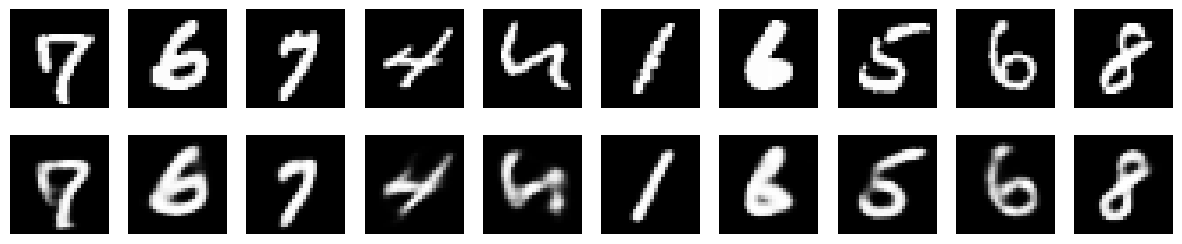


Generated Samples (Random Latent Noise -> Decoder)


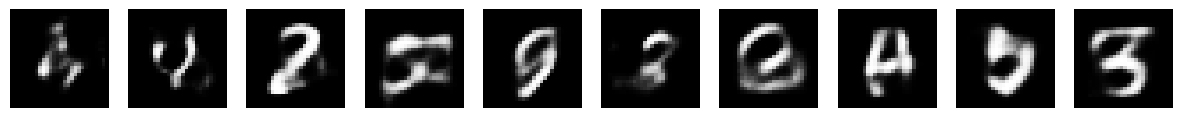

In [ ]:
# Evaluate
evaluate_vae(trained_model_FV, train_loader, input_dim, latent_dim)

**4. Describe the visualization of the outputs.**

#### Reconstructed Outputs (Top Two Rows)
With reference to the reconstructed Outputs (Top Two Rows), the model successfully learned to encode and decode the digits. The bottom row (reconstructions) closely matches the top row (originals). It preserved the identity of every digit (the "7" looks like a "7", the "6" like a "6", etc.).

Moreover, there is a little blur on the second row. This is a signature characteristic of VAEs. Because the model predicts a probability distribution (and uses Mean Squared Error loss), it tends to "average out" details, resulting in slightly fuzzy edges.

#### Generated Samples (Third Row)

Finally, these images were created from pure random noise ($z \sim N(0,1)$). The fact that they look like coherent digits (a "2", a "3", a "9", etc.) means our model has successfully learned the structure of the MNIST dataset.

Some images look like a mix between two digits (e.g., the first one looks like a cross between a "4" and a "9").This confirms our latent space is continuous. The model picked a random point in the "gap" between the "4 cluster" and the "9 cluster," so it generated a hybrid.

This is a success. It proves the VAE didn't just memorize the data but learned a smooth space where we can morph between concepts.

To conclude, our experiment was successful. The model balances reconstruction (it remembers what digits look like) and regularization (it can generate new valid digits from noise).